<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1742 | Val: 489 | Test: 276


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 4, accumulation steps = 8 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/janes/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100.0%


## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 8 micro-batches per optimizer step (effective batch size ≈ micro_batch x 8).
[EfficientNet-B0] Epoch   1/100 | LR: 1.00e-04 | train loss 1.2923 acc 0.380 | val loss 1.0559 acc 0.566 *
[EfficientNet-B0] Epoch   2/100 | LR: 1.00e-04 | train loss 1.0148 acc 0.596 | val loss 0.7800 acc 0.683 *
[EfficientNet-B0] Epoch   3/100 | LR: 1.00e-04 | train loss 0.8422 acc 0.656 | val loss 0.7979 acc 0.665
[EfficientNet-B0] Epoch   4/100 | LR: 1.00e-04 | train loss 0.7682 acc 0.693 | val loss 0.7634 acc 0.671 *
[EfficientNet-B0] Epoch   5/100 | LR: 1.00e-04 | train loss 0.7203 acc 0.709 | val loss 0.6438 acc 0.757 *
[EfficientNet-B0] Epoch   6/100 | LR: 1.00e-04 | train loss 0.6793 acc 0.716 | val loss 0.7058 acc 0.693
[EfficientNet-B0] Epoch   7/100 | LR: 1.00e-04 | train loss 0.6433 acc 0.718 | val loss 0.7037 acc 0.718
[EfficientNet-B0] Epoch   8/100 | LR: 1.00e-04 | train loss 0.5650 acc 0.754 | val loss 0.5719 acc 0.742 *
[EfficientNet-B0] Epoch   

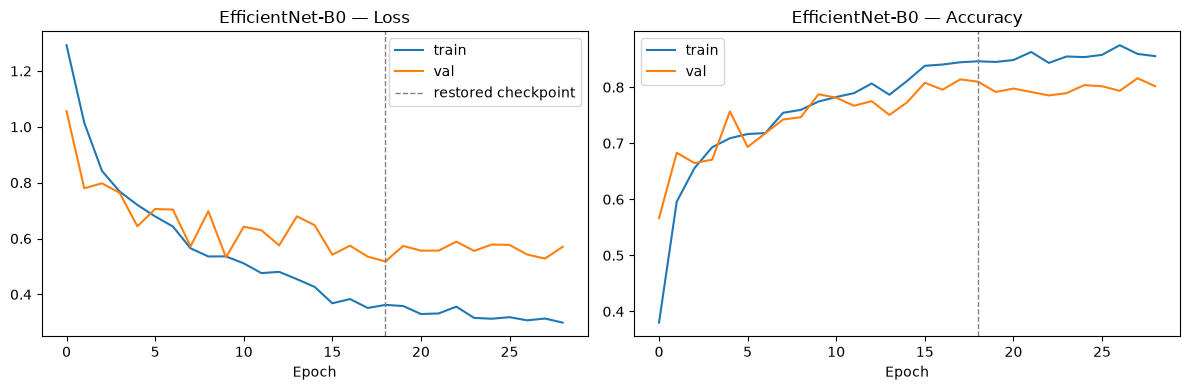

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.801


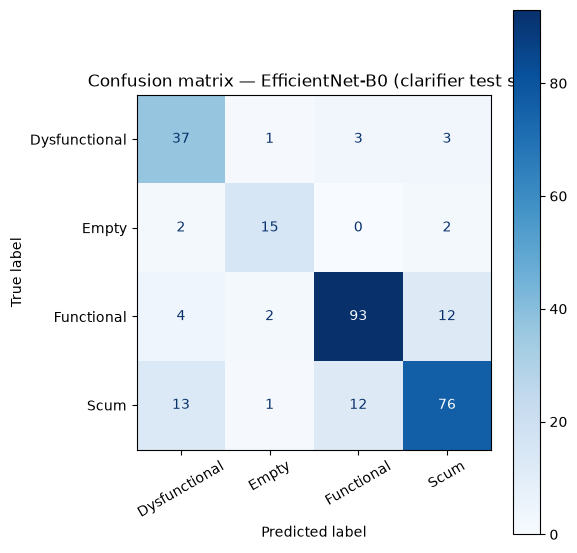

               precision    recall  f1-score   support

Dysfunctional      0.661     0.841     0.740        44
        Empty      0.789     0.789     0.789        19
   Functional      0.861     0.838     0.849       111
         Scum      0.817     0.745     0.779       102

     accuracy                          0.801       276
    macro avg      0.782     0.803     0.790       276
 weighted avg      0.808     0.801     0.802       276



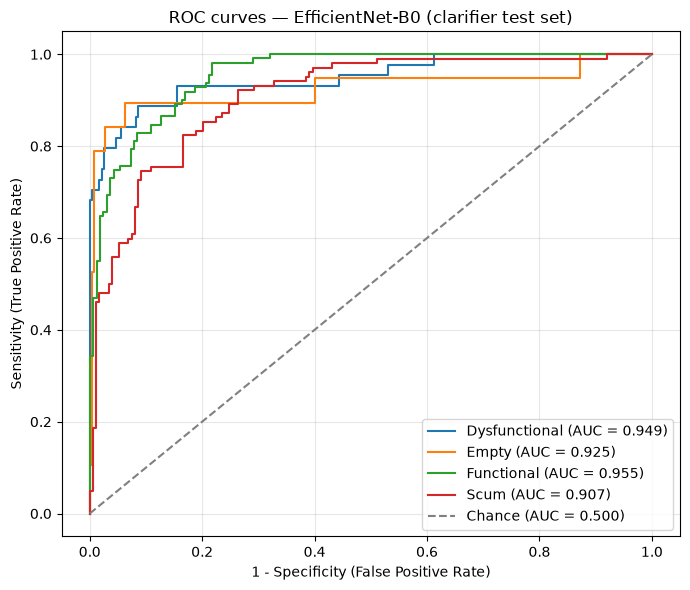

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.949
  Empty          : 0.925
  Functional     : 0.955
  Scum           : 0.907

Mean AUC: 0.934


(np.float64(0.8007246376811594),
 {'Dysfunctional': 0.948569749216301,
  'Empty': 0.924636493958632,
  'Functional': 0.9553371553371552,
  'Scum': 0.9068627450980393})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/results_efficientnet_b0.pkl
Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
